In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image
from PIL import Image
import seaborn as sns

2026-05-08 05:09:41.255221: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778216981.657855      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778216981.774770      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778216982.824038      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778216982.824092      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778216982.824095      57 computation_placer.cc:177] computation placer alr

In [2]:
train_dir = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"

test_dir  = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"

img_size = (224, 224)

batch_size = 16

In [3]:
print(os.listdir(train_dir))

print(os.listdir(test_dir))

['pituitary', 'notumor', 'meningioma', 'glioma']
['pituitary', 'notumor', 'meningioma', 'glioma']


In [4]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    
    rescale=1./255,
    
    rotation_range=25,
    
    zoom_range=0.25,
    
    shear_range=0.2,
    
    horizontal_flip=True,
    
    width_shift_range=0.1,
    
    height_shift_range=0.1
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    
    rescale=1./255
)

In [5]:
# Load data
train_generator = train_datagen.flow_from_directory(
    
    train_dir,
    
    target_size=img_size,
    
    batch_size=batch_size,
    
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    
    test_dir,
    
    target_size=img_size,
    
    batch_size=batch_size,
    
    class_mode='categorical'
)

print(train_generator.class_indices)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


Label: [1. 0. 0. 0.]


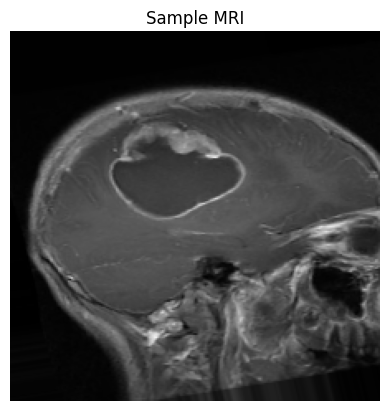

In [6]:
# Show sample image 
x_batch, y_batch = next(train_generator)

plt.imshow(x_batch[0])

plt.title("Sample MRI")

plt.axis("off")

print("Label:", y_batch[0])

plt.show()

In [7]:
# Restnet50v2 model
base_model = tf.keras.applications.ResNet50V2(
    
    include_top=False,
    
    weights='imagenet',
    
    input_shape=(224,224,3)
)

base_model.trainable = False

I0000 00:00:1778217241.416153      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778217241.422103      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
# Build model
inputs = layers.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)

x = layers.Dropout(0.6)(x)

outputs = layers.Dense(
    
    train_generator.num_classes,
    
    activation='softmax'
)(x)

model = tf.keras.Model(inputs, outputs)

In [9]:
# Compile model
model.compile(
    
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

In [10]:
# Call Backs
from tensorflow.keras.callbacks import (
    
    EarlyStopping,
    
    ReduceLROnPlateau,
    
    ModelCheckpoint
)

early_stop = EarlyStopping(
    
    monitor='val_loss',
    
    patience=3,
    
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    
    monitor='val_loss',
    
    factor=0.3,
    
    patience=2,
    
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    
    "best_model.keras",
    
    monitor='val_accuracy',
    
    save_best_only=True
)

In [11]:
# Train model
history = model.fit(
    
    train_generator,
    
    validation_data=val_generator,
    
    epochs=20,
    
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1778217420.181990     127 service.cc:152] XLA service 0x7ae984011ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778217420.182032     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778217420.182037     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778217421.992545     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/350 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.4844 - loss: 2.1054   

I0000 00:00:1778217428.075328     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


350/350 ━━━━━━━━━━━━━━━━━━━━ 115s 288ms/step - accuracy: 0.5213 - loss: 1.3414 - val_accuracy: 0.7763 - val_loss: 0.6461 - learning_rate: 1.0000e-04
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accuracy: 0.7361 - loss: 0.7284 - val_accuracy: 0.8144 - val_loss: 0.5583 - learning_rate: 1.0000e-04
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 74s 212ms/step - accuracy: 0.7907 - loss: 0.5544 - val_accuracy: 0.8338 - val_loss: 0.5131 - learning_rate: 1.0000e-04
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accuracy: 0.8149 - loss: 0.5186 - val_accuracy: 0.8475 - val_loss: 0.4843 - learning_rate: 1.0000e-04
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - accuracy: 0.8215 - loss: 0.4576 - val_accuracy: 0.8525 - val_loss: 0.4676 - learning_rate: 1.0000e-04
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - accuracy: 0.8268 - loss: 0.4516 - val_accuracy: 0.8600 - val_loss: 0.4525 - learning_rate: 1.0000e-04
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step -

In [12]:
# Fine tuning 
base_model.trainable = True

for layer in base_model.layers[:-30]:
    
    layer.trainable = False

In [13]:
# Recompile
model.compile(
    
    optimizer=tf.keras.optimizers.Adam(1e-5),
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

In [14]:
# Fine tuning  training
history_fine = model.fit(
    
    train_generator,
    
    validation_data=val_generator,
    
    epochs=10,
    
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 96s 227ms/step - accuracy: 0.8385 - loss: 0.4269 - val_accuracy: 0.8775 - val_loss: 0.4032 - learning_rate: 1.0000e-05
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.8846 - loss: 0.3089 - val_accuracy: 0.8906 - val_loss: 0.3799 - learning_rate: 1.0000e-05
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 75s 214ms/step - accuracy: 0.8973 - loss: 0.2802 - val_accuracy: 0.9038 - val_loss: 0.3600 - learning_rate: 1.0000e-05
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 76s 218ms/step - accuracy: 0.9117 - loss: 0.2317 - val_accuracy: 0.9131 - val_loss: 0.3577 - learning_rate: 1.0000e-05
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 75s 215ms/step - accuracy: 0.9132 - loss: 0.2271 - val_accuracy: 0.9175 - val_loss: 0.3552 - learning_rate: 1.0000e-05
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.9158 - loss: 0.2251 - val_accuracy: 0.9206 - val_loss: 0.3589 - learning_rate: 1.0000e-05
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 77s 21

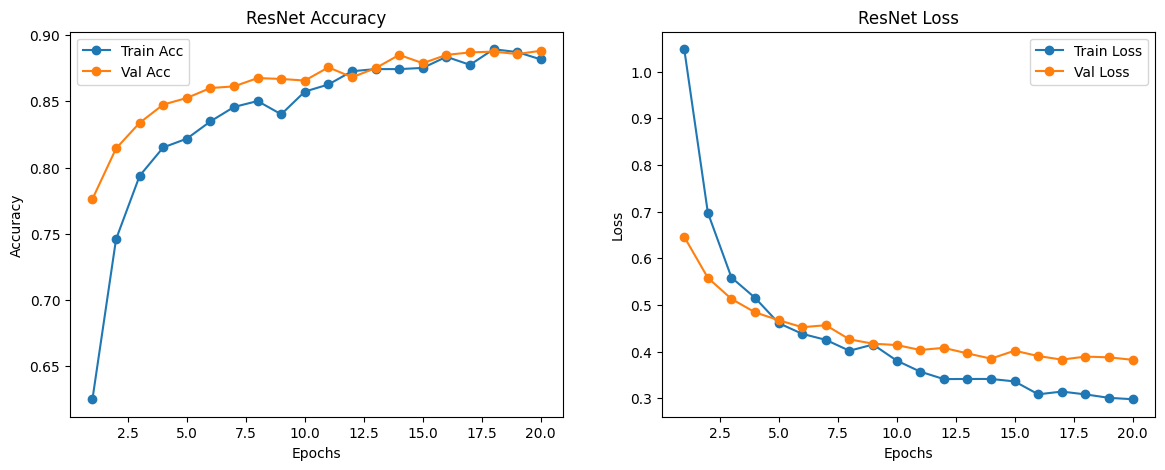

In [15]:
# Accuracy and Loss Graphs
acc = history.history['accuracy']

val_acc = history.history['val_accuracy']

loss = history.history['loss']

val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

# Accuracy

plt.subplot(1,2,1)

plt.plot(epochs, acc, 'o-', label='Train Acc')

plt.plot(epochs, val_acc, 'o-', label='Val Acc')

plt.title('ResNet Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

# Loss

plt.subplot(1,2,2)

plt.plot(epochs, loss, 'o-', label='Train Loss')

plt.plot(epochs, val_loss, 'o-', label='Val Loss')

plt.title('ResNet Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()

In [16]:
# Prediction Function
class_names = [
    'glioma',
    'meningioma',
    'notumor',
    'pituitary'
]

def predict_mri(img_path):

    img = Image.open(img_path).convert('RGB')

    img = img.resize((224, 224))

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = img_array / 255.0

    preds = model.predict(img_array, verbose=0)

    predicted_class = np.argmax(preds[0])

    confidence = preds[0][predicted_class] * 100

    plt.imshow(img)

    plt.title(
        f"{class_names[predicted_class]} ({confidence:.2f}%)"
    )

    plt.axis('off')

    plt.show()

    print("Prediction:", class_names[predicted_class])

    print("Confidence:", f"{confidence:.2f}%")

/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/glioma/Te-gl_248.jpg


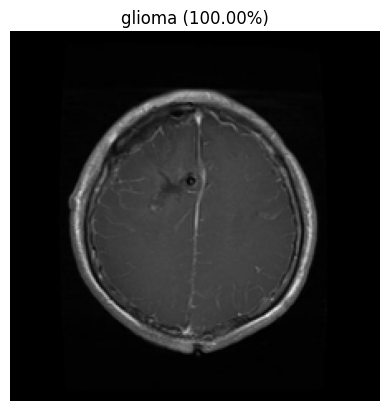

Prediction: glioma
Confidence: 100.00%


In [17]:
# Random Test Image
import random

test_folder = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/glioma"

all_images = os.listdir(test_folder)

random_image = random.choice(all_images)

img_path = os.path.join(
    test_folder,
    random_image
)

print(img_path)

predict_mri(img_path)

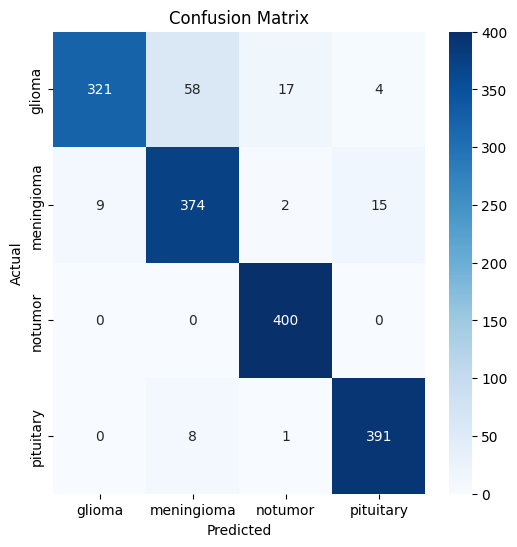


Classification Report:

              precision    recall  f1-score   support

      glioma       0.97      0.80      0.88       400
  meningioma       0.85      0.94      0.89       400
     notumor       0.95      1.00      0.98       400
   pituitary       0.95      0.98      0.97       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



In [18]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

val_generator.reset()

y_true = []

y_pred = []

for i in range(len(val_generator)):

    images, labels = val_generator[i]

    preds = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels, axis=1))

    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

class_names = list(
    val_generator.class_indices.keys()
)

plt.figure(figsize=(6,6))

sns.heatmap(
    
    cm,
    
    annot=True,
    
    fmt='d',
    
    cmap='Blues',
    
    xticklabels=class_names,
    
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

In [19]:
# Mobilenetv2model
base_model = tf.keras.applications.MobileNetV2(
    
    include_top=False,
    
    weights='imagenet',
    
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    
    train_generator.num_classes,
    
    activation='softmax'
)(x)

model = tf.keras.Model(inputs, outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
# Compile mobilenet
model.compile(
    
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

In [21]:
# Train mobilenet
checkpoint = ModelCheckpoint(
    
    "mobilenet_model.keras",
    
    monitor='val_accuracy',
    
    save_best_only=True
)

history = model.fit(
    
    train_generator,
    
    validation_data=val_generator,
    
    epochs=20,
    
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20


2026-05-08 05:58:31.163359: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 05:58:31.303079: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


350/350 ━━━━━━━━━━━━━━━━━━━━ 94s 217ms/step - accuracy: 0.5159 - loss: 1.4009 - val_accuracy: 0.7356 - val_loss: 0.7500 - learning_rate: 1.0000e-04
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 72s 205ms/step - accuracy: 0.7549 - loss: 0.6383 - val_accuracy: 0.7656 - val_loss: 0.7078 - learning_rate: 1.0000e-04
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 71s 204ms/step - accuracy: 0.8010 - loss: 0.5674 - val_accuracy: 0.7956 - val_loss: 0.6628 - learning_rate: 1.0000e-04
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 80s 229ms/step - accuracy: 0.8210 - loss: 0.4817 - val_accuracy: 0.7994 - val_loss: 0.6332 - learning_rate: 1.0000e-04
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 76s 217ms/step - accuracy: 0.8210 - loss: 0.4788 - val_accuracy: 0.8037 - val_loss: 0.6284 - learning_rate: 1.0000e-04
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 73s 209ms/step - accuracy: 0.8439 - loss: 0.4140 - val_accuracy: 0.8131 - val_loss: 0.6114 - learning_rate: 1.0000e-04
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 72s 206ms/step - 

In [22]:
# EfficientmobilenetB0model
base_model = tf.keras.applications.EfficientNetB0(
    
    include_top=False,
    
    weights='imagenet',
    
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(128, activation='relu')(x)

x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(
    
    train_generator.num_classes,
    
    activation='softmax'
)(x)

model = tf.keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
# Compile efficientnet
model.compile(
    
    optimizer=tf.keras.optimizers.Adam(1e-4),
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

In [24]:
# Train Efficientnet
history = model.fit(
    
    train_generator,
    
    validation_data=val_generator,
    
    epochs=20
)

Epoch 1/20


2026-05-08 06:29:41.534959: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 06:29:41.675772: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 06:29:41.998822: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 06:29:42.139970: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-08 06:29:42.934085: E external/local_xla/xla/stream_

350/350 ━━━━━━━━━━━━━━━━━━━━ 100s 220ms/step - accuracy: 0.2569 - loss: 1.5468 - val_accuracy: 0.3194 - val_loss: 1.3699
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 70s 200ms/step - accuracy: 0.3078 - loss: 1.4043 - val_accuracy: 0.4194 - val_loss: 1.3163
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 70s 201ms/step - accuracy: 0.3097 - loss: 1.3739 - val_accuracy: 0.4663 - val_loss: 1.2902
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.3545 - loss: 1.3292 - val_accuracy: 0.4000 - val_loss: 1.2788
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.3427 - loss: 1.3215 - val_accuracy: 0.4906 - val_loss: 1.2669
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 70s 200ms/step - accuracy: 0.3797 - loss: 1.2902 - val_accuracy: 0.4594 - val_loss: 1.2614
Epoch 7/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 70s 201ms/step - accuracy: 0.3740 - loss: 1.3059 - val_accuracy: 0.4900 - val_loss: 1.2526
Epoch 8/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.3685 - loss: 1.2911 - va

In [25]:
# Fine Tuning Efficient net 
base_model.trainable = True

for layer in base_model.layers[:-20]:
    
    layer.trainable = False

model.compile(
    
    optimizer=tf.keras.optimizers.Adam(1e-5),
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

history_fine = model.fit(
    
    train_generator,
    
    validation_data=val_generator,
    
    epochs=10,
    
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 103s 222ms/step - accuracy: 0.2519 - loss: 2.0583 - val_accuracy: 0.2412 - val_loss: 2.3633 - learning_rate: 1.0000e-05
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.3169 - loss: 1.6106 - val_accuracy: 0.3106 - val_loss: 1.4925 - learning_rate: 1.0000e-05
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 73s 208ms/step - accuracy: 0.3398 - loss: 1.4885 - val_accuracy: 0.3575 - val_loss: 1.4720 - learning_rate: 1.0000e-05
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 72s 205ms/step - accuracy: 0.3405 - loss: 1.4733 - val_accuracy: 0.3694 - val_loss: 1.3328 - learning_rate: 1.0000e-05
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.3511 - loss: 1.4106 - val_accuracy: 0.2887 - val_loss: 1.4616 - learning_rate: 1.0000e-05
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 72s 204ms/step - accuracy: 0.3620 - loss: 1.3522 - val_accuracy: 0.4381 - val_loss: 1.2690 - learning_rate: 1.0000e-05
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 73s 2

Testing Image: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/glioma/Te-gl_360.jpg
Prediction: notumor
Confidence: 100.00%


/tmp/ipykernel_57/794340840.py:130: RuntimeWarning: invalid value encountered in cast
  heatmap = np.uint8(255 * heatmap)
/tmp/ipykernel_57/794340840.py:133: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


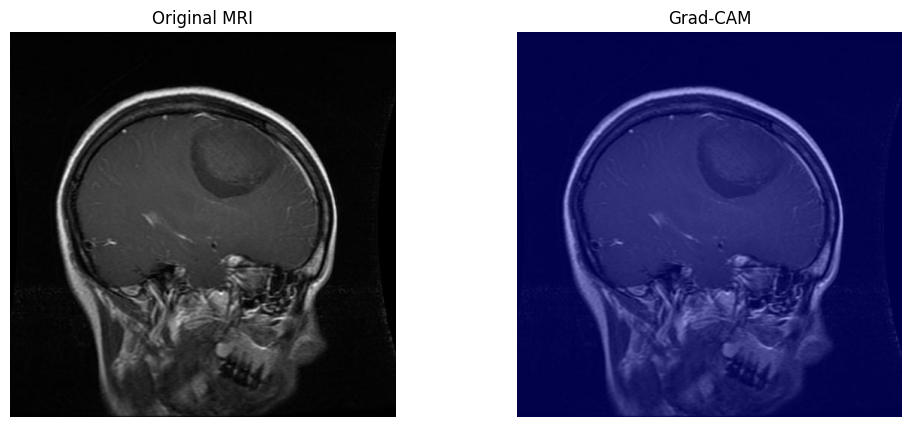

In [29]:
# =========================================================
# FINAL 100% WORKING GRADCAM FOR YOUR MODEL
# =========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import matplotlib.cm as cm
from tensorflow.keras.preprocessing import image
from PIL import Image
import random
import os

# =========================================================
# LAST CONVOLUTION LAYER
# =========================================================

LAST_CONV_LAYER = "top_conv"

# =========================================================
# GRADCAM FUNCTION
# =========================================================

def make_gradcam_heatmap(img_array):

    # Get EfficientNet model
    efficientnet = model.layers[1]

    # Last convolution layer
    last_conv_layer = efficientnet.get_layer(
        LAST_CONV_LAYER
    )

    # Create feature extractor
    feature_extractor = tf.keras.Model(
        efficientnet.input,
        last_conv_layer.output
    )

    # Create classifier model
    classifier_input = tf.keras.Input(
        shape=last_conv_layer.output.shape[1:]
    )

    x = classifier_input

    # Remaining layers after EfficientNet
    for layer in model.layers[2:]:
        x = layer(x)

    classifier_model = tf.keras.Model(
        classifier_input,
        x
    )

    # Convert image tensor
    img_tensor = tf.convert_to_tensor(
        img_array,
        dtype=tf.float32
    )

    # Compute gradients
    with tf.GradientTape() as tape:

        # Feature maps
        conv_outputs = feature_extractor(
            img_tensor
        )

        tape.watch(conv_outputs)

        # Predictions
        predictions = classifier_model(
            conv_outputs
        )

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    # Gradients
    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    # Mean gradients
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Create heatmap
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0)

    heatmap /= tf.math.reduce_max(heatmap)

    return heatmap.numpy()

# =========================================================
# DISPLAY FUNCTION
# =========================================================

def display_gradcam(img_path, heatmap, alpha=0.4):

    # Load original image
    img = cv2.imread(img_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # Resize heatmap
    heatmap = cv2.resize(
        heatmap,
        (img.shape[1], img.shape[0])
    )

    # Convert heatmap
    heatmap = np.uint8(255 * heatmap)

    # Apply colormap
    jet = cm.get_cmap("jet")

    jet_colors = jet(np.arange(256))[:, :3]

    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.preprocessing.image.array_to_img(
        jet_heatmap
    )

    jet_heatmap = jet_heatmap.resize(
        (img.shape[1], img.shape[0])
    )

    jet_heatmap = tf.keras.preprocessing.image.img_to_array(
        jet_heatmap
    )

    # Overlay heatmap
    superimposed_img = (
        jet_heatmap * alpha + img
    )

    superimposed_img = tf.keras.preprocessing.image.array_to_img(
        superimposed_img
    )

    # Plot images
    plt.figure(figsize=(12,5))

    # Original
    plt.subplot(1,2,1)

    plt.imshow(img)

    plt.title("Original MRI")

    plt.axis("off")

    # GradCAM
    plt.subplot(1,2,2)

    plt.imshow(superimposed_img)

    plt.title("Grad-CAM")

    plt.axis("off")

    plt.show()

# =========================================================
# RUN GRADCAM
# =========================================================

def run_gradcam(img_path):

    # Load image
    img = Image.open(img_path).convert("RGB")

    img = img.resize((224,224))

    # Convert image
    img_array = image.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # IMPORTANT
    # EfficientNet already preprocesses internally

    # Prediction
    preds = model.predict(
        img_array,
        verbose=0
    )

    pred_class = np.argmax(preds[0])

    confidence = preds[0][pred_class] * 100

    print(
        "Prediction:",
        class_names[pred_class]
    )

    print(
        "Confidence:",
        f"{confidence:.2f}%"
    )

    # Generate heatmap
    heatmap = make_gradcam_heatmap(
        img_array
    )

    # Display GradCAM
    display_gradcam(
        img_path,
        heatmap
    )

# =========================================================
# TEST GRADCAM
# =========================================================

test_folder = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing/glioma"

all_images = os.listdir(test_folder)

random_image = random.choice(all_images)

img_path = os.path.join(
    test_folder,
    random_image
)

print("Testing Image:", img_path)

run_gradcam(img_path)